> ### EEE6503-01: Computer Vision

# Project #1 : Architecture Design

**<div style="text-align: right"> Due date: Apr. 24th, 2026. </div>** 
**<div style="text-align: right"> Please upload your file @ learnus by 11:00 PM. </div>** 

### *Assignment Instructions:*
1. You can use both Korean and English for your report.
2. **Analyze the algorithm, theoretically and empirically.** 
3. **Report your results.**   

<h2><span style="color:blue">2025314228</span> </h2>

In [2]:
import datetime
print("This code is written at " + str(datetime.datetime.now()))

This code is written at 2026-04-22 11:31:34.536011


In [3]:
import os

import torch
import torch.nn as nn
import torchvision
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import matplotlib.pyplot as plt
import numpy as np

from torchvision.transforms import transforms
from torch.utils.data import DataLoader

In [4]:
# Define transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

# Create datasets and dataloaders
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

/home/siyeolkim/micromamba/envs/diffusion-models/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [5]:
transform_example = transforms.Compose([
    transforms.ToTensor()
])

class_names = trainset.classes
dataset_example = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_example)

# visualize some images from the training set
def visualize_example_images(dataset):
    indices = np.random.choice(len(dataset), 10, replace=False)
    imgs_and_labels = [dataset[i] for i in indices]

    plt.figure(figsize=(15, 8))
    for idx, (img, label) in enumerate(imgs_and_labels):
        plt.subplot(2, 5, idx + 1)
        img = img.numpy().transpose((1, 2, 0))
        plt.imshow(img)
        plt.title(class_names[label], fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

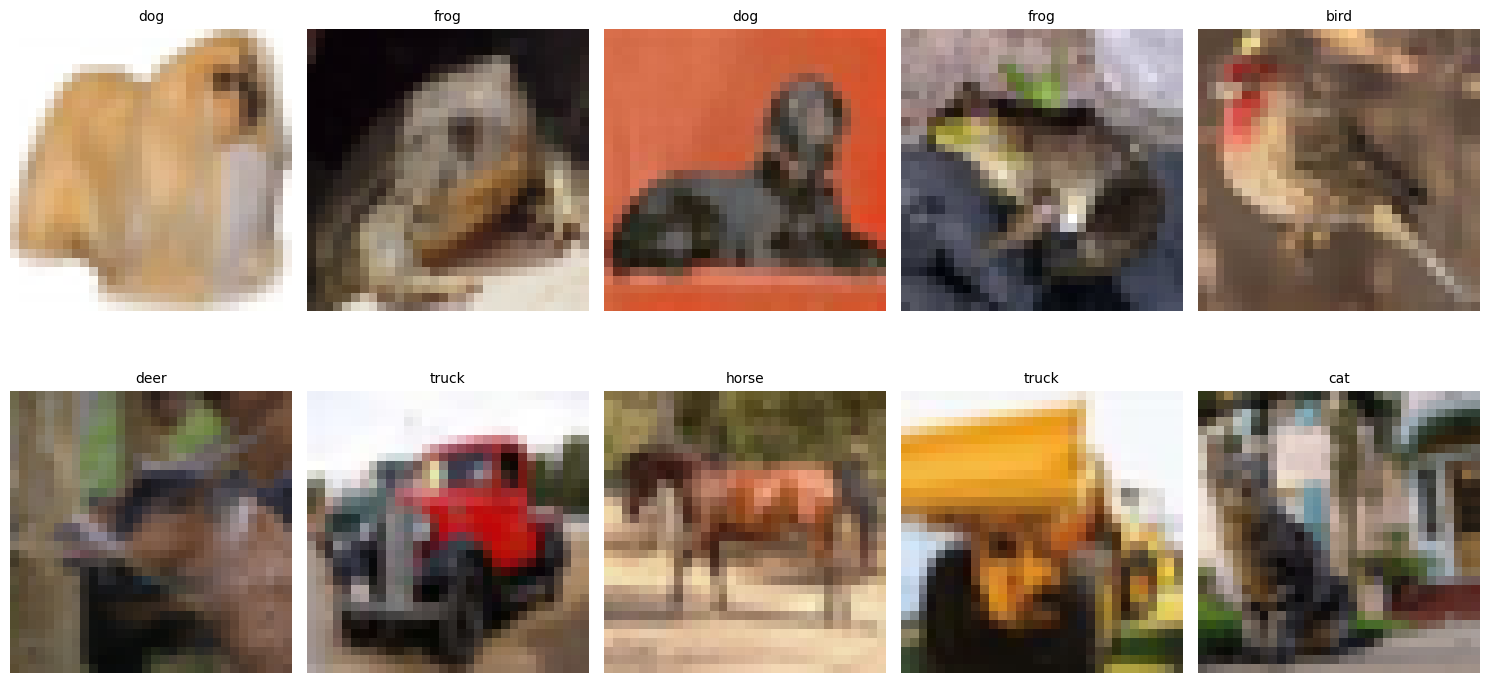

In [6]:
visualize_example_images(dataset_example)

In [7]:
from torchvision.models import resnet50, shufflenet_v2_x1_0, mobilenet_v2

# Load models
model = resnet50(weights=None)
# model = shufflenet_v2_x1_0(weights=None)
# model = mobilenet_v2(weights=None)

# Modify the final fully connected layer for resnet50, shufflenet_v2_x1_0
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

# Modify the final fully connected layer for mobilenet_v2
# num_features = model.classifier[1].in_features
# model.classifier[1] = nn.Linear(num_features, 10)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
model = model.cuda()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Using device: cuda
Total number of parameters: 23528522


In [8]:
# Instantiate loss, optimizer, and scheduler
# You must not change the loss function and the optimizer when training your model.
learning_rate = 0.1
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
scheduler = lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.2)

In [9]:
# Train the model
num_epochs = 45

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(trainloader):.4f}")

Epoch 1, Loss: 4.8520
Epoch 2, Loss: 2.0239
Epoch 3, Loss: 1.8725
Epoch 4, Loss: 1.7428
Epoch 5, Loss: 1.6489
Epoch 6, Loss: 1.5628
Epoch 7, Loss: 1.4830
Epoch 8, Loss: 1.4164
Epoch 9, Loss: 1.3339
Epoch 10, Loss: 1.2699
Epoch 11, Loss: 1.2312
Epoch 12, Loss: 1.1582
Epoch 13, Loss: 1.1204
Epoch 14, Loss: 1.0870
Epoch 15, Loss: 1.0578
Epoch 16, Loss: 0.8521
Epoch 17, Loss: 0.7905
Epoch 18, Loss: 0.7628
Epoch 19, Loss: 0.7388
Epoch 20, Loss: 0.7253
Epoch 21, Loss: 0.7067
Epoch 22, Loss: 0.6956
Epoch 23, Loss: 0.6811
Epoch 24, Loss: 0.6728
Epoch 25, Loss: 0.6586
Epoch 26, Loss: 0.6476
Epoch 27, Loss: 0.6362
Epoch 28, Loss: 0.6246
Epoch 29, Loss: 0.6135
Epoch 30, Loss: 0.6071
Epoch 31, Loss: 0.4984
Epoch 32, Loss: 0.4538
Epoch 33, Loss: 0.4400
Epoch 34, Loss: 0.4257
Epoch 35, Loss: 0.4150
Epoch 36, Loss: 0.4065
Epoch 37, Loss: 0.4032
Epoch 38, Loss: 0.3911
Epoch 39, Loss: 0.3868
Epoch 40, Loss: 0.3807
Epoch 41, Loss: 0.3705
Epoch 42, Loss: 0.3685
Epoch 43, Loss: 0.3633
Epoch 44, Loss: 0.35

In [10]:
# Evaluate the model
# resnet50
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy of the network on the 10000 test images: {100 * correct / total:.2f}%")
# resnet50: 0.8401

Accuracy of the network on the 10000 test images: 83.06%


In [11]:
# Evaluate the model
# shufflenet_v2_x1_0
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy of the network on the 10000 test images: {100 * correct / total:.2f}%")
# shufflenet_v2_x1_0: 0.7755

Accuracy of the network on the 10000 test images: 83.06%


In [12]:
# Evaluate the model
# mobilenet_v2
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy of the network on the 10000 test images: {100 * correct / total:.2f}%")
# mobilenet_v2: 0.8301

Accuracy of the network on the 10000 test images: 83.06%


In [ ]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from typing import List


# ============================================================
#  STE-based TopK mask
# ============================================================
class StraightThroughTopK(torch.autograd.Function):
    @staticmethod
    def forward(ctx, scores: torch.Tensor, k: int) -> torch.Tensor:
        B, C, H, W = scores.shape
        flat = scores.view(B, -1)
        topk_vals, _ = torch.topk(flat, k, dim=1)
        threshold = topk_vals[:, -1].view(B, 1, 1, 1)
        return (scores >= threshold).float()

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None  # STE: identity


def topk_mask(scores: torch.Tensor, rho: float) -> torch.Tensor:
    B, _, H, W = scores.shape
    k = max(1, int(rho * H * W))
    return StraightThroughTopK.apply(scores, k)


# ============================================================
#  Sparse Spatial Gate
# ============================================================
class SparseSpatialGate(nn.Module):
    def __init__(self, in_channels: int, rho: float = 0.5):
        super().__init__()
        self.rho = rho
        self.gate_conv = nn.Conv2d(in_channels, 1, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        scores = torch.sigmoid(self.bn(self.gate_conv(x)))  # (B,1,H,W)
        mask = topk_mask(scores, self.rho)                   # hard binary
        return x * mask


# ============================================================
#  Recursive Feature Pyramid Fusion
# ============================================================
class RecursivePyramidFusion(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 scales: List[int] = None):
        super().__init__()
        if scales is None:
            scales = [1, 2]
        self.scales = scales

        self.branch_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )
            for _ in scales
        ])

        # SE-like learned fusion weights
        self.se = nn.Sequential(
            nn.Linear(len(scales), max(1, len(scales) // 2)),
            nn.ReLU(inplace=True),
            nn.Linear(max(1, len(scales) // 2), len(scales)),
            nn.Softmax(dim=-1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        branch_feats = []

        for s, conv in zip(self.scales, self.branch_convs):
            if s == 1:
                feat = conv(x)
            else:
                pooled = F.avg_pool2d(x, kernel_size=s, stride=s,
                                      padding=0, ceil_mode=True)
                feat = conv(pooled)
                feat = F.interpolate(feat, size=(H, W),
                                     mode='bilinear', align_corners=False)
            branch_feats.append(feat)

        # compute per-scale importance
        scale_summary = torch.stack(
            [f.mean(dim=[1, 2, 3]) for f in branch_feats], dim=1
        )  # (B, S)
        alphas = self.se(scale_summary)  # (B, S)

        out = sum(
            alphas[:, i].view(B, 1, 1, 1) * branch_feats[i]
            for i in range(len(self.scales))
        )
        return out


# ============================================================
#  SAGBlock
# ============================================================
class SAGBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 stride: int = 1, rho: float = 0.5,
                 scales: List[int] = None):
        super().__init__()

        # Sparse gate path
        self.gate = SparseSpatialGate(in_channels, rho=rho)
        self.sparse_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3,
                      stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

        # Pyramid fusion path
        self.stride_pool = (
            nn.AvgPool2d(kernel_size=stride, stride=stride)
            if stride > 1 else nn.Identity()
        )
        self.pyramid = RecursivePyramidFusion(
            in_channels, out_channels, scales=scales
        )

        # Post-merge
        self.bn_out = nn.BatchNorm2d(out_channels)
        self.relu_out = nn.ReLU(inplace=True)

        # Skip
        self.skip = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1,
                      stride=stride, bias=False),
            nn.BatchNorm2d(out_channels),
        ) if (in_channels != out_channels or stride != 1) else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.skip(x)
        out_sparse = self.sparse_conv(self.gate(x))
        out_pyr = self.pyramid(self.stride_pool(x))
        out = self.relu_out(self.bn_out(out_sparse + out_pyr) + identity)
        return out


# ============================================================
#  SAG-Net CIFAR-10
# ============================================================
class SAGNet(nn.Module):
    """
    SAG-Net adapted for CIFAR-10 (32x32 input).
    Stem is a single 3x3 conv (stride=1) to avoid premature downsampling.
    """

    def __init__(self, num_classes: int = 10,
                 n_blocks: List[int] = None,
                 rho: float = 0.5,
                 scales: List[int] = None):
        super().__init__()
        if n_blocks is None:
            n_blocks = [2, 2, 2, 2]
        if scales is None:
            scales = [1, 2]

        stage_channels = [64, 64, 128, 256, 512]

        # CIFAR stem: 3x3 conv, stride 1, no maxpool
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        # Build stages
        self.stages = nn.ModuleList()
        in_ch = stage_channels[0]
        for i, (out_ch, n) in enumerate(zip(stage_channels[1:], n_blocks)):
            stride = 1 if i == 0 else 2
            blocks = []
            for j in range(n):
                blocks.append(SAGBlock(
                    in_channels=in_ch if j == 0 else out_ch,
                    out_channels=out_ch,
                    stride=stride if j == 0 else 1,
                    rho=rho,
                    scales=scales,
                ))
            self.stages.append(nn.Sequential(*blocks))
            in_ch = out_ch

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(stage_channels[-1], num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        for stage in self.stages:
            x = stage(x)
        return self.head(x)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def build_dataloaders(data_root: str = './data', batch_size: int = 128,
                      num_workers: int = 2):
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])

    transform_example = transforms.Compose([
        transforms.ToTensor()
    ])

    trainset = torchvision.datasets.CIFAR10(root=data_root, train=True,
                                            download=True, transform=transform_train)
    trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    dataset_example = torchvision.datasets.CIFAR10(root=data_root, train=True,
                                                    download=True, transform=transform_example)
    class_names = trainset.classes

    testset = torchvision.datasets.CIFAR10(root=data_root, train=False,
                                           download=True, transform=transform_test)
    testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

    return trainloader, testloader, class_names, dataset_example


def train_one_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), \
                       labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type,
                            enabled=(device.type == 'cuda')):
            logits = model(imgs)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        # gradient clipping to stabilise sparse gate training
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), \
                       labels.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, 100.0 * correct / total


def main():
    # ---------- config ----------
    EPOCHS     = 45
    RHO        = 0.5   
    SCALES     = [1, 2]
    DATA_ROOT  = './data'
    SAVE_PATH  = './sagnet_cifar10_best.pth'
    # ----------------------------

    device = torch.device(
        'cuda' if torch.cuda.is_available() else
        'mps'  if torch.backends.mps.is_available() else 'cpu'
    )
    print(f"Device: {device}")

    train_loader, val_loader, class_names, dataset_example = build_dataloaders(DATA_ROOT)

    model = SAGNet(num_classes=10, rho=RHO, scales=SCALES).to(device)
    print(f"Parameters: {model.count_parameters() / 1e6:.2f} M")

    learning_rate = 0.1
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate,
                          momentum=0.9, weight_decay=5e-4)
    scheduler = StepLR(optimizer, step_size=15, gamma=0.2)
    scaler    = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

    best_acc = 0.0
    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device, scaler
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        elapsed = time.time() - t0
        print(
            f"Epoch [{epoch:3d}/{EPOCHS}]  "
            f"train loss={train_loss:.4f} acc={train_acc:.2f}%  "
            f"val loss={val_loss:.4f} acc={val_acc:.2f}%  "
            f"lr={scheduler.get_last_lr()[0]:.5f}  "
            f"time={elapsed:.1f}s"
        )

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_acc': val_acc,
                'rho': RHO,
            }, SAVE_PATH)
            print(f"  ✓ saved best model  (val acc={best_acc:.2f}%)")

    print(f"\nBest validation accuracy: {best_acc:.2f}%")


if __name__ == "__main__":
    main()

Device: cuda
Parameters: 14.35 M
Epoch [  1/45]  train loss=2.0605 acc=31.86%  val loss=1.6771 acc=41.98%  lr=0.10000  time=43.8s
  ✓ saved best model  (val acc=41.98%)
Epoch [  2/45]  train loss=1.4626 acc=49.78%  val loss=1.4025 acc=57.45%  lr=0.10000  time=40.9s
  ✓ saved best model  (val acc=57.45%)
Epoch [  3/45]  train loss=1.0769 acc=62.05%  val loss=1.0688 acc=62.52%  lr=0.10000  time=43.7s
  ✓ saved best model  (val acc=62.52%)
Epoch [  4/45]  train loss=0.8189 acc=71.08%  val loss=0.8062 acc=71.78%  lr=0.10000  time=42.3s
  ✓ saved best model  (val acc=71.78%)
Epoch [  5/45]  train loss=0.6831 acc=76.38%  val loss=0.7309 acc=74.67%  lr=0.10000  time=42.5s
  ✓ saved best model  (val acc=74.67%)
Epoch [  6/45]  train loss=0.6107 acc=78.86%  val loss=0.7016 acc=75.79%  lr=0.10000  time=43.6s
  ✓ saved best model  (val acc=75.79%)
Epoch [  7/45]  train loss=0.5512 acc=81.28%  val loss=0.7161 acc=75.75%  lr=0.10000  time=44.9s
Epoch [  8/45]  train loss=0.5180 acc=82.19%  val loss

In [ ]:
# ============================================================
#  Efficient SAG-Net (parameter-reduced variant)
#  Applied changes vs. baseline SAGNet:
#    (1) Depthwise-separable 3x3 conv in place of full 3x3 conv
#    (2) Single conv shared across pyramid scales
#    (3) Sparse path merged into pyramid (gate applied to scale=1 branch)
#    (4) Width multiplier (default 0.75x) on stage channels
# ============================================================


class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, kernel_size=3,
            stride=stride, padding=1, groups=in_channels, bias=False,
        )
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(
            in_channels, out_channels, kernel_size=1, bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.relu(self.bn1(self.depthwise(x)))
        x = self.bn2(self.pointwise(x))
        return x


class EfficientSAGBlock(nn.Module):
    """
    Merged sparse + pyramid block:
      - stride pool (if stride > 1) first, so downsampling is decoupled
      - a SINGLE depthwise-separable conv is shared across all scales
      - the sparse gate is applied only to the primary (scale=1) branch,
        removing the need for a parallel sparse_conv path
    """

    def __init__(self, in_channels: int, out_channels: int,
                 stride: int = 1, rho: float = 0.5,
                 scales: List[int] = None):
        super().__init__()
        if scales is None:
            scales = [1, 2]
        self.scales = scales

        self.stride_pool = (
            nn.AvgPool2d(kernel_size=stride, stride=stride)
            if stride > 1 else nn.Identity()
        )

        self.gate = SparseSpatialGate(in_channels, rho=rho)
        self.shared_conv = DepthwiseSeparableConv(
            in_channels, out_channels, stride=1
        )

        self.se = nn.Sequential(
            nn.Linear(len(scales), max(1, len(scales) // 2)),
            nn.ReLU(inplace=True),
            nn.Linear(max(1, len(scales) // 2), len(scales)),
            nn.Softmax(dim=-1),
        )

        self.bn_out = nn.BatchNorm2d(out_channels)
        self.relu_out = nn.ReLU(inplace=True)

        self.skip = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1,
                      stride=stride, bias=False),
            nn.BatchNorm2d(out_channels),
        ) if (in_channels != out_channels or stride != 1) else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B = x.shape[0]
        identity = self.skip(x)

        x_pooled = self.stride_pool(x)
        H, W = x_pooled.shape[-2:]

        branch_feats = []
        for s in self.scales:
            if s == 1:
                feat = self.shared_conv(self.gate(x_pooled))
            else:
                pooled = F.avg_pool2d(
                    x_pooled, kernel_size=s, stride=s,
                    padding=0, ceil_mode=True,
                )
                feat = self.shared_conv(pooled)
                feat = F.interpolate(
                    feat, size=(H, W),
                    mode='bilinear', align_corners=False,
                )
            branch_feats.append(feat)

        scale_summary = torch.stack(
            [f.mean(dim=[1, 2, 3]) for f in branch_feats], dim=1
        )
        alphas = self.se(scale_summary)

        out = sum(
            alphas[:, i].view(B, 1, 1, 1) * branch_feats[i]
            for i in range(len(self.scales))
        )
        out = self.relu_out(self.bn_out(out) + identity)
        return out


class EfficientSAGNet(nn.Module):
    def __init__(self, num_classes: int = 10,
                 n_blocks: List[int] = None,
                 rho: float = 0.5,
                 scales: List[int] = None,
                 width_mult: float = 0.75):
        super().__init__()
        if n_blocks is None:
            n_blocks = [2, 2, 2, 2]
        if scales is None:
            scales = [1, 2]

        base_channels = [64, 64, 128, 256, 512]
        stage_channels = [max(8, int(c * width_mult)) for c in base_channels]

        self.stem = nn.Sequential(
            nn.Conv2d(3, stage_channels[0], kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.BatchNorm2d(stage_channels[0]),
            nn.ReLU(inplace=True),
        )

        self.stages = nn.ModuleList()
        in_ch = stage_channels[0]
        for i, (out_ch, n) in enumerate(zip(stage_channels[1:], n_blocks)):
            stride = 1 if i == 0 else 2
            blocks = []
            for j in range(n):
                blocks.append(EfficientSAGBlock(
                    in_channels=in_ch if j == 0 else out_ch,
                    out_channels=out_ch,
                    stride=stride if j == 0 else 1,
                    rho=rho,
                    scales=scales,
                ))
            self.stages.append(nn.Sequential(*blocks))
            in_ch = out_ch

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(stage_channels[-1], num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        for stage in self.stages:
            x = stage(x)
        return self.head(x)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ----- Quick parameter-count comparison -----
_baseline = SAGNet(num_classes=10, rho=0.5, scales=[1, 2])
_efficient = EfficientSAGNet(num_classes=10, rho=0.5, scales=[1, 2],
                              width_mult=0.75)
print(f"Baseline  SAGNet         : {_baseline.count_parameters() / 1e6:.2f} M")
print(f"Efficient SAGNet (0.75x) : {_efficient.count_parameters() / 1e6:.2f} M")
print(f"Reduction ratio          : "
      f"{_efficient.count_parameters() / _baseline.count_parameters():.3f}x")
del _baseline, _efficient

In [ ]:
# A scatter plot comparing the models

In [ ]:
# Evaluate the model
# SAGNet (loaded from sagnet_cifar10_best.pth)
sagnet_model = SAGNet(num_classes=10, rho=0.5, scales=[1, 2]).to(device)
checkpoint = torch.load('./sagnet_cifar10_best.pth', map_location=device)
sagnet_model.load_state_dict(checkpoint['model_state_dict'])

sagnet_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = sagnet_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy of the network on the 10000 test images: {100 * correct / total:.2f}%")